[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol13_notebook_curs.ipynb)

# Capitolul 13: Machine Learning în finanțe — Notebook de curs

**Modelarea piețelor financiare (MFM)** · Academia de Studii Economice din București · Daniel Traian Pele

Acest notebook reproduce, pas cu pas, rezultatele empirice din cursul Capitolului 9, pe date reale
(S&P 500 și VIX, 2000–2026):

1. Raportul semnal/zgomot: ce se poate (și ce nu se poate) prezice în randamente
2. Caracteristici și variabilă țintă fără look-ahead
3. Compromisul bias–varianță (arbori de decizie vs păduri aleatoare)
4. Regularizarea LASSO
5. Diferențierea fracționară (FFD) și ordinul minim $d^*$
6. Etichetarea prin metoda celor trei bariere
7. Validarea încrucișată cu purjare (Purged K-Fold) și experimentul de scurgere a informației
8. Compararea modelelor cu validare purjată
9. Importanța caracteristicilor: MDI, MDA, SHAP
10. Backtest walk-forward cu costuri de tranzacționare
11. Teorema strategiei false
12. Deflated Sharpe Ratio

Timp de rulare: aproximativ 3–5 minute în Colab.

## 0. Configurare

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip -q install shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Paleta de culori MFM
MainBlue, IDAred, Forest, Amber = '#1A3A6E', '#CD0000', '#2E7D32', '#B5853F'
Orange, Purple, Gray, LightGray = '#E67E22', '#8E44AD', '#7F7F7F', '#DADADA'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
                     'font.size': 9, 'axes.titlesize': 10, 'legend.frameon': False,
                     'figure.dpi': 110, 'figure.facecolor': 'none', 'axes.facecolor': 'none',
                     'savefig.facecolor': 'none', 'savefig.transparent': True})
SEED = 42


def legend_bottom(ax, ncol=2, y=-0.25, handles=None, labels=None, **kw):
    """Legenda în afara graficului, jos-centru (stilul graficelor MFM)."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)

In [3]:
import os
DATA_URL = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
SERIES = {'sp500': 'GSPC.INDX', 'vix': 'VIX.INDX', 'btc': 'BTC-USD.CC', 'eth': 'ETH-USD.CC'}
START = {'sp500': '2000-01-01', 'vix': '2000-01-01', 'btc': '2014-09-17', 'eth': '2015-08-07'}


def load_data(name='sp500', start=None, end='2026-09-18'):
    """OHLCV zilnic din folderul de date al cursului data/market: copia locală, altfel fișierul din repo-ul GitHub MFM."""
    fname = SERIES[name] + '.csv'
    local = [os.path.join(d, 'data', 'market', fname) for d in ('.', '..', '../..', '../../..')]
    path = next((p for p in local if os.path.exists(p)), DATA_URL + fname)
    df = pd.read_csv(path, parse_dates=['date']).set_index('date')
    df = df.rename(columns=str.capitalize)[['Open', 'High', 'Low', 'Close', 'Volume']]
    return df.loc[start or START[name]:end]


spx = load_data('sp500')['Close']
vix = load_data('vix')['Close']
log_spx = np.log(spx)
print('S&P 500:', spx.index[0].date(), '->', spx.index[-1].date(), len(spx), 'obs')

S&P 500: 2000-01-03 -> 2026-09-18 6718 obs


## 1. Raportul semnal/zgomot

Randamentele zilnice $r_t$ sunt aproape necorelate, în timp ce randamentele absolute $|r_t|$ au o
autocorelație puternică și persistentă (gruparea volatilității). **Direcția este aproape imposibil de
prezis, riscul este previzibil.** De aceea $R^2$ în afara eșantionului pentru prognoza randamentelor este,
de regulă, mult sub 1%, chiar și cu cele mai bune modele de machine learning (Gu, Kelly & Xiu, 2020),
iar orice afirmație de tipul „90% acuratețe" pentru direcția zilnică trebuie să ridice imediat suspiciunea
de scurgere a informației (leakage) sau de supraajustare (overfitting).

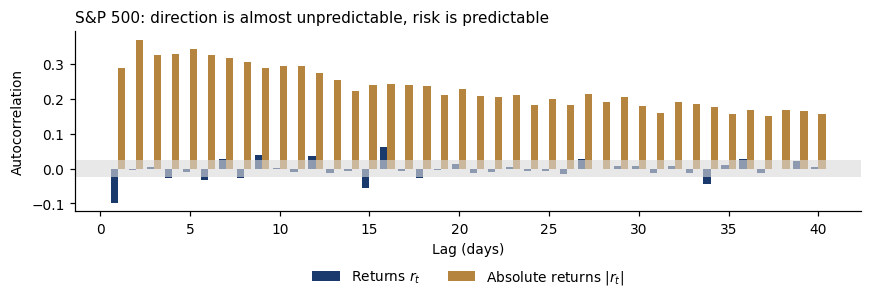

             lb_stat  lb_pvalue
r_t   5      71.2115        0.0
      20    162.0015        0.0
|r_t| 5    3695.8552        0.0
      20  10893.8332        0.0


In [4]:
r = log_spx.diff().dropna()
lags = np.arange(1, 41)
ac_r = [r.autocorr(l) for l in lags]
ac_a = [r.abs().autocorr(l) for l in lags]
band = 1.96 / np.sqrt(len(r))                     # banda de 95% sub i.i.d.

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lags - 0.2, ac_r, 0.4, color=MainBlue, label='Returns $r_t$')
ax.bar(lags + 0.2, ac_a, 0.4, color=Amber, label='Absolute returns $|r_t|$')
ax.axhspan(-band, band, color=LightGray, alpha=0.6, lw=0)
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.set_title('S&P 500: direction is almost unpredictable, risk is predictable', loc='left')
legend_bottom(ax, ncol=2)
plt.tight_layout(); plt.show()

lb = pd.concat({'r_t': acorr_ljungbox(r, lags=[5, 20]), '|r_t|': acorr_ljungbox(r.abs(), lags=[5, 20])})
print(lb.round(4))

## 2. Caracteristici și variabila țintă

Prezicem **direcția pe 5 zile** $y_t = \mathbb{1}\{\log P_{t+5} - \log P_t > 0\}$ pe baza unor
caracteristici tehnice calculate numai cu informația disponibilă până la momentul $t$: momentum pe
1–120 zile, volatilitate realizată, distanța față de mediile mobile, RSI și VIX.

Pentru fiecare observație reținem și $t_1$, data la care eticheta devine cunoscută ($t+5$ zile de
tranzacționare). Deoarece etichetele consecutive se suprapun în timp, observațiile **nu sunt i.i.d.** —
acest lucru contează la validarea încrucișată (Secțiunea 7).

In [5]:
def ffd_weights(d, threshold=1e-4, max_size=10_000):
    """w_k = -w_{k-1} (d - k + 1) / k, trunchiate când |w_k| < threshold."""
    w = [1.0]
    for k in range(1, max_size):
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
    return np.array(w)


def frac_diff_ffd(series, d, threshold=1e-4):
    """Diferențiere fracționară cu fereastră fixă: X~_t = sum_k w_k X_{t-k}."""
    w = ffd_weights(d, threshold)
    x = series.dropna().values
    out = np.convolve(x, w, mode='valid')
    return pd.Series(out, index=series.dropna().index[len(w) - 1:])


def rsi(close, n=14):
    delta = close.diff()
    up = delta.clip(lower=0).ewm(alpha=1 / n).mean()
    dn = (-delta.clip(upper=0)).ewm(alpha=1 / n).mean()
    return 100 - 100 / (1 + up / dn)


def build_features(close, vix=None, d_ffd=None):
    """Caracteristici care folosesc doar informația disponibilă la momentul t (fără look-ahead)."""
    lp = np.log(close)
    r = lp.diff()
    f = pd.DataFrame(index=close.index)
    for h in (1, 5, 20, 60, 120):
        f[f'mom_{h}'] = lp.diff(h)                                     # momentum pe h zile
    f['vol_20'] = r.rolling(20).std() * np.sqrt(252)
    f['vol_60'] = r.rolling(60).std() * np.sqrt(252)
    f['vol_ratio'] = f['vol_20'] / f['vol_60']
    f['dist_ma50'] = lp - lp.rolling(50).mean()
    f['dist_ma200'] = lp - lp.rolling(200).mean()
    f['rsi_14'] = rsi(close) / 100
    if vix is not None:
        v = np.log(vix.reindex(close.index).ffill())
        f['vix_level'] = v
        f['vix_chg_5'] = v.diff(5)
    if d_ffd is not None:
        f['ffd_price'] = frac_diff_ffd(lp, d_ffd)
    return f


def sharpe_ratio(returns, periods=252):
    """Sharpe anualizat (rată fără risc zero)."""
    r = np.asarray(returns)
    return np.sqrt(periods) * r.mean() / r.std(ddof=1)


H = 5                                              # orizontul etichetei (zile)
feats = build_features(spx, vix=vix)
FEATS = list(feats.columns)
fwd = log_spx.shift(-H) - log_spx
df = feats.assign(fwd=fwd).dropna().loc['2001-01-01':]
df['y'] = (df['fwd'] > 0).astype(int)
pos = np.searchsorted(spx.index, df.index)
df['t1'] = spx.index[np.minimum(pos + H, len(spx) - 1)]   # când se cunoaște eticheta
print(df.shape, '| share of "up" labels:', round(df['y'].mean(), 3))
df[FEATS].describe().T.round(3)

(6461, 16) | share of "up" labels: 0.577


,count,mean,std,min,25%,50%,75%,max
mom_1,6461.0,0.000,0.012,-0.128,-0.005,0.001,0.006,0.110
mom_5,6461.0,0.001,0.025,-0.203,-0.010,0.003,0.014,0.175
mom_20,6461.0,0.005,0.047,-0.370,-0.015,0.012,0.032,0.211
mom_60,6461.0,0.016,0.077,-0.533,-0.017,0.030,0.063,0.330
mom_120,6461.0,0.031,0.112,-0.605,-0.018,0.051,0.097,0.421
vol_20,6461.0,0.161,0.106,0.033,0.097,0.134,0.191,0.979
vol_60,6461.0,0.166,0.096,0.050,0.109,0.135,0.198,0.740
vol_ratio,6461.0,0.972,0.245,0.322,0.797,0.969,1.136,1.696
dist_ma50,6461.0,0.007,0.041,-0.317,-0.010,0.015,0.032,0.137
dist_ma200,6461.0,0.025,0.084,-0.495,-0.008,0.045,0.078,0.193


## 3. Compromisul bias–varianță

Antrenăm pe 2001–2017 și testăm pe 2018–2026. Observațiile de antrenare a căror fereastră de etichetă
intră în perioada de test sunt eliminate (o *purjare* simplă). Pe măsură ce crește adâncimea unui singur
arbore de decizie, acuratețea pe setul de antrenare explodează, iar cea pe setul de test nu se
îmbunătățește: complexitatea suplimentară modelează doar zgomotul. Media multor arbori decorelați
(pădurea aleatoare) reduce varianța, dar nu poate crea un semnal care nu există. Linia punctată este
reperul naiv „prezice mereu creștere".

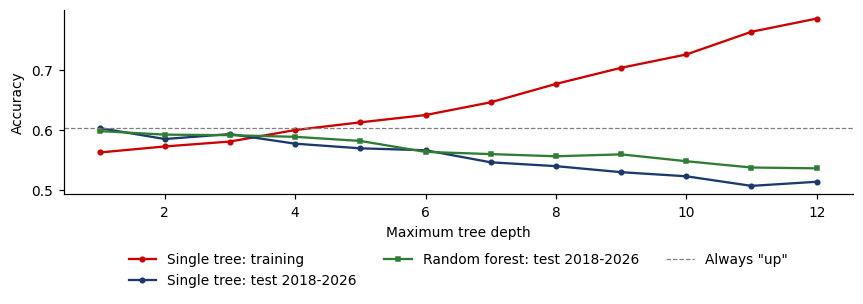

,tree_train,tree_test,rf_test
depth,,,
1,0.562,0.603,0.598
2,0.572,0.585,0.592
3,0.581,0.593,0.591
4,0.600,0.577,0.589
5,0.613,0.569,0.582
6,0.625,0.566,0.563
7,0.646,0.546,0.560
8,0.677,0.540,0.556
9,0.704,0.530,0.559


In [6]:
train_mask = df.index < '2018-01-01'
test_start = df.index[~train_mask][0]
train_idx = df.index[train_mask & (df['t1'] < test_start)]      # purjăm granița antrenare/test
test_idx = df.index[~train_mask]
Xtr, ytr = df.loc[train_idx, FEATS], df.loc[train_idx, 'y']
Xte, yte = df.loc[test_idx, FEATS], df.loc[test_idx, 'y']

rows = []
for depth in range(1, 13):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, max_features='sqrt',
                                n_jobs=-1, random_state=SEED).fit(Xtr, ytr)
    rows.append((depth, accuracy_score(ytr, tree.predict(Xtr)), accuracy_score(yte, tree.predict(Xte)),
                 accuracy_score(yte, rf.predict(Xte))))
bv = pd.DataFrame(rows, columns=['depth', 'tree_train', 'tree_test', 'rf_test']).set_index('depth')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(bv.index, bv['tree_train'], 'o-', color=IDAred, ms=3, label='Single tree: training')
ax.plot(bv.index, bv['tree_test'], 'o-', color=MainBlue, ms=3, label='Single tree: test 2018-2026')
ax.plot(bv.index, bv['rf_test'], 's-', color=Forest, ms=3, label='Random forest: test 2018-2026')
ax.axhline(yte.mean(), color=Gray, ls='--', lw=0.8, label='Always "up"')
ax.set_xlabel('Maximum tree depth'); ax.set_ylabel('Accuracy'); legend_bottom(ax, ncol=3)
plt.tight_layout(); plt.show()
bv.round(3)

## 4. Regularizarea LASSO

Regresia logistică penalizată $L_1$ rezolvă
$$\min_{\beta_0,\boldsymbol\beta}\; -\frac1n\sum_{t}\Big[y_t\log p_t + (1-y_t)\log(1-p_t)\Big] + \lambda\,\|\boldsymbol\beta\|_1,
\qquad p_t = \frac{1}{1+e^{-(\beta_0 + \mathbf x_t^\top\boldsymbol\beta)}}.$$
Penalizarea $L_1$ aduce coeficienții **exact la zero**, realizând astfel selecția variabilelor.
Caracteristicile sunt standardizate numai pe setul de antrenare. Graficul arată traiectoria
coeficienților pe măsură ce $\lambda$ scade; panoul din dreapta arată AUC pe setul de test pentru fiecare $\lambda$.

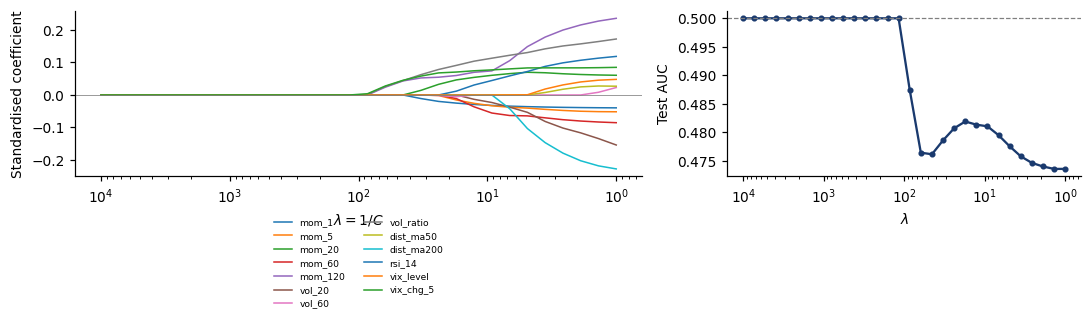

cel mai bun model nevid: C = 0.01172, test AUC = 0.487, caracteristici = ['vol_ratio', 'vix_chg_5']
Bate vreo penalizare clar modelul constant (AUC = 0,5)? Priviți tabelul.


,C,n_nonzero,test_AUC
0,0.0001,0,0.5000
3,0.0003,0,0.5000
6,0.0007,0,0.5000
9,0.0017,0,0.5000
12,0.0045,0,0.5000
15,0.0117,2,0.4875
18,0.0304,5,0.4786
21,0.0788,9,0.4814
24,0.2043,11,0.4776
27,0.5298,12,0.4740


In [7]:
scaler = StandardScaler().fit(Xtr)                   # estimat doar pe datele de antrenare
Ztr, Zte = scaler.transform(Xtr), scaler.transform(Xte)
Cs = np.logspace(-4, 0, 30)
coefs, aucs = [], []
for C in Cs:
    m = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=5000).fit(Ztr, ytr)
    coefs.append(m.coef_.ravel())
    aucs.append(roc_auc_score(yte, m.predict_proba(Zte)[:, 1]) if np.any(m.coef_) else 0.5)
coefs = np.array(coefs)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={'width_ratios': [1.6, 1]})
for i, name in enumerate(FEATS):
    axes[0].plot(1 / Cs, coefs[:, i], lw=1, label=name)
axes[0].set_xscale('log'); axes[0].invert_xaxis(); axes[0].axhline(0, color=Gray, lw=0.5)
axes[0].set_xlabel(r'$\lambda = 1/C$'); axes[0].set_ylabel('Standardised coefficient')
legend_bottom(axes[0], ncol=2, y=-0.2, fontsize=6)
axes[1].plot(1 / Cs, aucs, 'o-', ms=3, color=MainBlue); axes[1].axhline(0.5, color=Gray, ls='--', lw=0.8)
axes[1].set_xscale('log'); axes[1].invert_xaxis(); axes[1].set_xlabel(r'$\lambda$'); axes[1].set_ylabel('Test AUC')
plt.tight_layout(); plt.show()

nz = (coefs != 0).sum(1)
lasso = pd.DataFrame({'C': Cs, 'n_nonzero': nz, 'test_AUC': aucs})
best = int(np.argmax(np.where(nz > 0, aucs, -np.inf)))
print(f'cel mai bun model nevid: C = {Cs[best]:.4g}, test AUC = {aucs[best]:.3f}, '
      f'caracteristici = {[f for f, c in zip(FEATS, coefs[best]) if c != 0]}')
print('Bate vreo penalizare clar modelul constant (AUC = 0,5)? Priviți tabelul.')
lasso.iloc[::3].round(4)

## 5. Diferențierea fracționară

Prețurile sunt nestaționare ($d=0$); randamentele ($d=1$) sunt staționare, dar au șters memoria nivelului.
Diferențierea fracționară aplică $(1-B)^d$ cu un $d\in(0,1)$ real:
$$\tilde X_t = \sum_{k=0}^{\infty} w_k X_{t-k},\qquad w_0 = 1,\quad w_k = -w_{k-1}\,\frac{d-k+1}{k}.$$
Cu fereastră fixă (FFD), ponderile sunt trunchiate când $|w_k|<\tau$ ($\tau=10^{-4}$). Căutăm **cel mai
mic $d^*$** pentru care testul ADF respinge rădăcina unitară la 5% — seria este atunci staționară,
dar păstrează cât mai multă memorie (corelație mare cu log-prețul inițial).

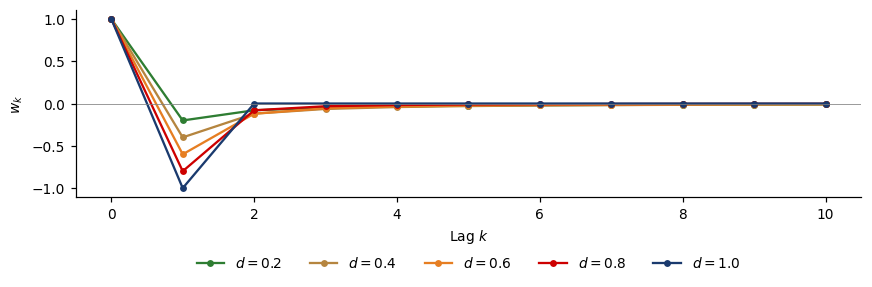

d* = 0.25 | corelația cu log-prețul = 0.984


d,0.00,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,...,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.00
adf,0.840,0.165,-0.528,-1.243,-1.986,-2.964,-4.124,-5.584,-7.499,-9.830,...,-16.185,-20.223,-24.876,-30.035,-35.419,-41.092,-46.546,-51.976,-56.866,-61.619
crit_5%,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,...,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862,-2.862
corr,1.000,1.000,0.998,0.996,0.991,0.984,0.975,0.961,0.941,0.915,...,0.827,0.763,0.684,0.595,0.502,0.407,0.319,0.233,0.154,0.028


In [8]:
fig, ax = plt.subplots(figsize=(8, 2.8))
for d, c in zip([0.2, 0.4, 0.6, 0.8, 1.0], [Forest, Amber, Orange, IDAred, MainBlue]):
    w = ffd_weights(d, threshold=0, max_size=11)
    ax.plot(range(len(w)), w, marker='o', ms=3.5, color=c, label=f'$d={d}$')
ax.axhline(0, color=Gray, lw=0.5); ax.set_xlabel('Lag $k$'); ax.set_ylabel('$w_k$'); legend_bottom(ax, ncol=5)
plt.tight_layout(); plt.show()


def find_min_d(logp, grid=np.round(np.arange(0, 1.01, 0.05), 2)):
    """Cel mai mic d pentru care seria FFD este staționară (ADF, 5%)."""
    rows = []
    for d in grid:
        x = frac_diff_ffd(logp, d).dropna()
        adf = adfuller(x, maxlag=1, regression='c', autolag=None)
        rows.append((d, adf[0], adf[4]['5%'], np.corrcoef(logp.loc[x.index], x)[0, 1]))
    out = pd.DataFrame(rows, columns=['d', 'adf', 'crit_5%', 'corr']).set_index('d')
    return out, out.index[out['adf'] < out['crit_5%']].min()


ffd_table, d_star = find_min_d(log_spx)
print('d* =', d_star, '| corelația cu log-prețul =', round(ffd_table.loc[d_star, 'corr'], 3))
ffd_table.round(3).T

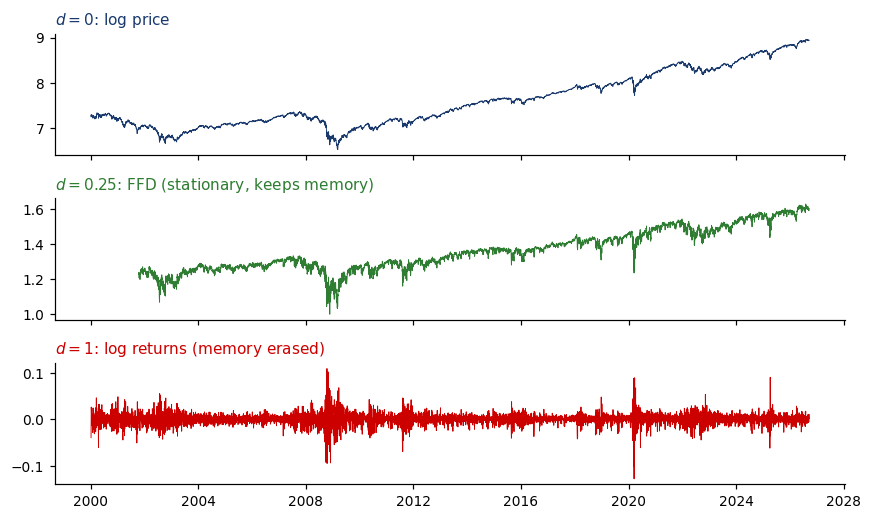

(6269, 17)


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8, 4.8), sharex=True)
panels = [(log_spx, MainBlue, '$d=0$: log price'),
          (frac_diff_ffd(log_spx, d_star), Forest, f'$d={d_star}$: FFD (stationary, keeps memory)'),
          (log_spx.diff(), IDAred, '$d=1$: log returns (memory erased)')]
for ax, (s, c, t) in zip(axes, panels):
    ax.plot(s.index, s.values, color=c, lw=0.6); ax.set_title(t, loc='left', color=c)
plt.tight_layout(); plt.show()

# adăugăm prețul FFD ca o caracteristică suplimentară
df['ffd_price'] = frac_diff_ffd(log_spx, d_star).reindex(df.index)
df = df.dropna()
FEATS = FEATS + ['ffd_price']
print(df.shape)

## 6. Metoda celor trei bariere

Etichetele cu orizont fix ignoră traiectoria prețului și regimul de volatilitate. **Metoda celor trei
bariere** (López de Prado, 2018) deschide, la fiecare eveniment $t_0$, trei bariere:

* superioară (realizarea profitului): $\log P_t - \log P_{t_0} \ge \text{pt}\cdot\sigma_{t_0}\sqrt h$ → eticheta $+1$
* inferioară (stop-loss): $\log P_t - \log P_{t_0} \le -\text{sl}\cdot\sigma_{t_0}\sqrt h$ → eticheta $-1$
* verticală (limita de timp) la $t_0 + h$ → eticheta = semnul randamentului (sau „time-out")

unde $\sigma_{t_0}$ este o estimare EWMA a volatilității zilnice. Prima barieră atinsă stabilește eticheta și momentul $t_1$.

          Orizont fix (10z)  Trei bariere
+1                    0.605         0.196
-1                    0.395         0.213
time-out              0.000         0.590


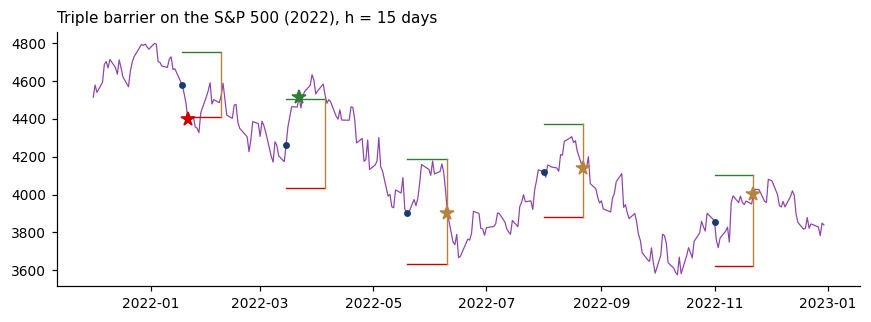

In [10]:
def get_daily_vol(close, span=50):
    """Volatilitatea EWMA a randamentelor logaritmice zilnice."""
    return np.log(close).diff().ewm(span=span).std()


def triple_barrier(close, events_idx, vol, pt=1.0, sl=1.0, horizon=10):
    """Etichete cu trei bariere: +1 sus, -1 jos, semnul randamentului la bariera verticală."""
    logp = np.log(close)
    pos = {t: i for i, t in enumerate(close.index)}
    rows = []
    for t0 in events_idx:
        i0 = pos[t0]
        if i0 + 1 >= len(close) or np.isnan(vol.iloc[i0]):
            continue
        i1 = min(i0 + horizon, len(close) - 1)
        width = vol.iloc[i0] * np.sqrt(horizon)
        path = logp.iloc[i0 + 1:i1 + 1] - logp.iloc[i0]
        up = path[path >= pt * width].index.min() if pt > 0 else pd.NaT
        dn = path[path <= -sl * width].index.min() if sl > 0 else pd.NaT
        first = min([t for t in (up, dn) if pd.notna(t)], default=pd.NaT)
        if pd.isna(first):
            t1, barrier = close.index[i1], 'vertical'
            label = int(np.sign(path.iloc[-1])) if len(path) else 0
        else:
            t1 = first
            barrier = 'upper' if first == up else 'lower'
            label = 1 if barrier == 'upper' else -1
        rows.append((t0, t1, logp.loc[t1] - logp.iloc[i0], label, barrier, width))
    return pd.DataFrame(rows, columns=['t0', 't1', 'ret', 'label', 'barrier', 'width']).set_index('t0')


vol = get_daily_vol(spx)
events = spx.index[250:-20]
tb = triple_barrier(spx, events, vol, pt=1.0, sl=1.0, horizon=10)
fixed = np.sign(log_spx.shift(-10) - log_spx).reindex(tb.index)
shares = pd.DataFrame({'Orizont fix (10z)': [np.mean(fixed > 0), np.mean(fixed < 0), 0.0],
                       'Trei bariere': tb['barrier'].value_counts(normalize=True)
                           .reindex(['upper', 'lower', 'vertical']).values},
                      index=['+1', '-1', 'time-out'])
print(shares.round(3))

# ilustrare pe 2022
close = spx.loc['2021-12-01':'2022-12-31']
ev = [close.index[close.index.searchsorted(t)] for t in ['2022-01-18', '2022-03-15', '2022-05-19', '2022-08-01', '2022-11-01']]
tb_ex = triple_barrier(close, ev, vol.reindex(close.index), pt=1.0, sl=1.0, horizon=15)
colors = {'upper': Forest, 'lower': IDAred, 'vertical': Amber}
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(close.index, close.values, color=Purple, lw=0.8)
for t0, row in tb_ex.iterrows():
    p0, i0 = close.loc[t0], close.index.get_loc(t0)
    tv = close.index[min(i0 + 15, len(close) - 1)]
    up, dn = p0 * np.exp(row['width']), p0 * np.exp(-row['width'])
    ax.plot([t0, tv], [up, up], color=Forest, lw=0.9); ax.plot([t0, tv], [dn, dn], color=IDAred, lw=0.9)
    ax.plot([tv, tv], [dn, up], color=Amber, lw=0.9); ax.plot(t0, p0, 'o', color=MainBlue, ms=3.5)
    ax.plot(row['t1'], close.loc[row['t1']], '*', ms=9, color=colors[row['barrier']])
ax.set_title('Triple barrier on the S&P 500 (2022), h = 15 days', loc='left')
plt.tight_layout(); plt.show()

## 7. Purged K-Fold și experimentul de scurgere a informației

Când etichetele se suprapun, o observație de antrenare vecină cu setul de test împarte cea mai mare
parte a ferestrei etichetei cu observațiile de test: K-Fold standard (cu amestecare) **scurge**
informație din setul de test în cel de antrenare. **Purjarea** elimină din antrenare observațiile al căror
$[t_0, t_1]$ se suprapune cu perioada de test, iar **embargoul** elimină și o mică zonă-tampon după aceasta.

*Experiment:* un mers aleator pur (nimic nu este previzibil), etichete = semnul mișcării pe următoarele
20 de zile, caracteristici = zgomot persistent (medii mobile pe 20 de zile ale unui zgomot alb).
K-Fold cu amestecare „găsește" un semnal; Purged K-Fold raportează corect o aruncare de monedă.

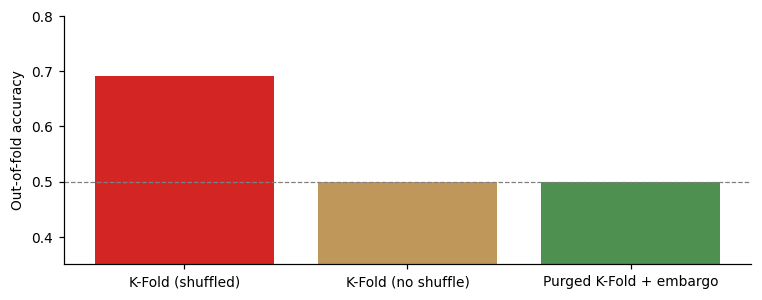

K-Fold (shuffled)          0.691
K-Fold (no shuffle)        0.500
Purged K-Fold + embargo    0.499
dtype: float64

In [11]:
class PurgedKFold:
    """K-Fold fără amestecare pentru etichete suprapuse.

    t1: pd.Series indexată după momentul observației t0, valoare = momentul t1 când eticheta devine cunoscută.
    Purjare: eliminăm din antrenare observațiile al căror [t0, t1] se suprapune cu perioada de test.
    Embargo: eliminăm și o fracțiune pct_embargo de observații imediat după setul de test.
    """

    def __init__(self, n_splits=5, t1=None, pct_embargo=0.01):
        self.n_splits, self.t1, self.pct_embargo = n_splits, t1, pct_embargo

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        idx = np.arange(len(X))
        t0, t1 = self.t1.index.values, self.t1.values
        embargo = int(len(X) * self.pct_embargo)
        for test in np.array_split(idx, self.n_splits):
            start, stop = test[0], test[-1]
            test_t0, test_t1 = t0[start], t1[test].max()
            before = idx[t1 < test_t0]                                  # etichete cunoscute înainte de test
            after_start = min(stop + 1 + embargo, len(X))               # embargo
            after = idx[after_start:][t0[after_start:] > test_t1]       # încep după ultima etichetă de test
            yield np.concatenate([before, after]), test


rng = np.random.default_rng(SEED)
n, h = 3000, 20
p = pd.Series(np.cumsum(rng.normal(0, 0.01, n + h)))                  # mers aleator pur
y_leak = (p.shift(-h) - p > 0).astype(int).iloc[:n].values             # etichete suprapuse pe 20 de zile
X_leak = np.column_stack([pd.Series(rng.normal(size=n + h)).rolling(h).mean().bfill().iloc[:n] for _ in range(5)])
t1_leak = pd.Series(np.arange(n) + h, index=np.arange(n))

schemes = {'K-Fold (shuffled)': KFold(5, shuffle=True, random_state=SEED),
           'K-Fold (no shuffle)': KFold(5, shuffle=False),
           'Purged K-Fold + embargo': PurgedKFold(5, t1=t1_leak, pct_embargo=0.01)}
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
leak = {}
for name, cv in schemes.items():
    leak[name] = np.mean([accuracy_score(y_leak[te], model.fit(X_leak[tr], y_leak[tr]).predict(X_leak[te]))
                          for tr, te in cv.split(X_leak)])

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(range(3), list(leak.values()), color=[IDAred, Amber, Forest], alpha=0.85)
ax.axhline(0.5, color=Gray, ls='--', lw=0.8)
ax.set_xticks(range(3), list(leak.keys())); ax.set_ylim(0.35, 0.8); ax.set_ylabel('Out-of-fold accuracy')
plt.tight_layout(); plt.show()
pd.Series(leak).round(3)

## 8. Compararea modelelor cu validare purjată

Patru familii de modele, fiecare evaluată cu Purged 5-Fold CV (embargo 1%) pe direcția S&P 500 la 5 zile.
Reperul relevant nu este 50%, ci ponderea clasei majoritare în fiecare fold de test („mereu în sus").

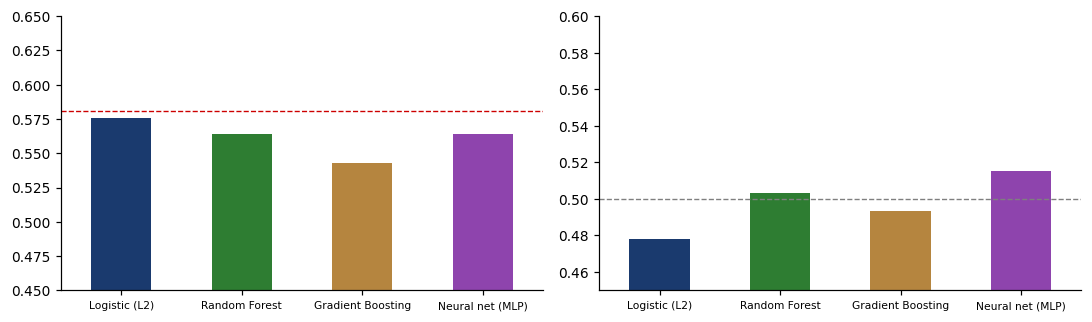

,accuracy,AUC,always_up
model,,,
Logistic (L2),0.576,0.478,0.581
Random Forest,0.564,0.504,0.581
Gradient Boosting,0.543,0.493,0.581
Neural net (MLP),0.564,0.515,0.581


In [12]:
models = {
    'Logistic (L2)': make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000)),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=100, max_features='sqrt',
                                            n_jobs=-1, random_state=SEED),
    'Gradient Boosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=200,
                                                        min_samples_leaf=100, random_state=SEED),
    'Neural net (MLP)': make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-2,
                                                                      early_stopping=True, max_iter=500,
                                                                      random_state=SEED)),
}
X, y = df[FEATS].values, df['y'].values
cv = PurgedKFold(5, t1=df['t1'], pct_embargo=0.01)
rows = []
for name, m in models.items():
    acc, auc, base = [], [], []
    for tr, te in cv.split(X):
        prob = m.fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        acc.append(accuracy_score(y[te], prob > 0.5)); auc.append(roc_auc_score(y[te], prob))
        base.append(max(y[te].mean(), 1 - y[te].mean()))
    rows.append((name, np.mean(acc), np.mean(auc), np.mean(base)))
comp = pd.DataFrame(rows, columns=['model', 'accuracy', 'AUC', 'always_up']).set_index('model')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
comp['accuracy'].plot.bar(ax=axes[0], color=[MainBlue, Forest, Amber, Purple], rot=0)
axes[0].axhline(comp['always_up'].mean(), color=IDAred, ls='--', lw=0.9); axes[0].set_ylim(0.45, 0.65)
comp['AUC'].plot.bar(ax=axes[1], color=[MainBlue, Forest, Amber, Purple], rot=0)
axes[1].axhline(0.5, color=Gray, ls='--', lw=0.9); axes[1].set_ylim(0.45, 0.6)
for ax in axes: ax.tick_params(axis='x', labelsize=7); ax.set_xlabel('')
plt.tight_layout(); plt.show()
comp.round(3)

## 9. Importanța caracteristicilor: MDI, MDA, SHAP

* **MDI** (scăderea medie a impurității): calculată în eșantion, din arbori; favorizează caracteristicile
  continue, cu multe valori distincte, și nu „vede" supraajustarea.
* **MDA** (scăderea medie a acurateței / importanța prin permutare): scăderea AUC în afara eșantionului
  când o caracteristică este amestecată aleator; valorile negative arată că acea caracteristică *strică*
  performanța în afara eșantionului.
* **SHAP**: atribuiri bazate pe valorile Shapley ale fiecărei predicții către caracteristici (Lundberg & Lee, 2017).

Antrenăm pe primele 70% din eșantion; evaluăm pe ultimele 30%, după un interval de purjare/embargo.

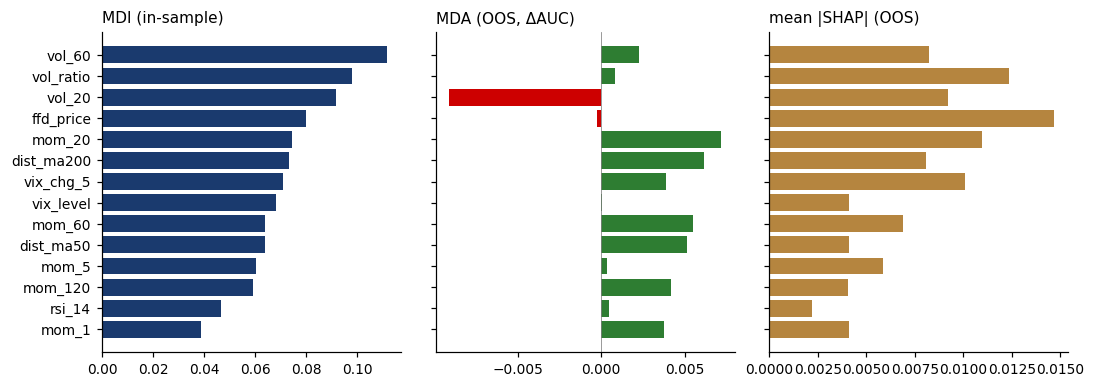

,MDI,MDA,SHAP
mom_20,0.0743,0.0072,0.0110
dist_ma200,0.0731,0.0061,0.0081
mom_60,0.0640,0.0055,0.0069
dist_ma50,0.0638,0.0051,0.0041
mom_120,0.0592,0.0042,0.0040
vix_chg_5,0.0708,0.0039,0.0101
mom_1,0.0389,0.0038,0.0041
vol_60,0.1115,0.0022,0.0082
vol_ratio,0.0980,0.0008,0.0124
rsi_14,0.0465,0.0005,0.0022


In [13]:
Xdf = df[FEATS]
split = int(len(df) * 0.7)
gap = split + H + int(0.01 * len(df))                     # purjare + embargo
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=100, max_features='sqrt',
                            n_jobs=-1, random_state=SEED).fit(Xdf.iloc[:split], y[:split])
mdi = pd.Series(rf.feature_importances_, index=FEATS)
mda = pd.Series(permutation_importance(rf, Xdf.iloc[gap:], y[gap:], scoring='roc_auc', n_repeats=5,
                                       random_state=SEED, n_jobs=-1).importances_mean, index=FEATS)
try:
    import shap
    sample = Xdf.iloc[gap:].sample(300, random_state=SEED)
    sv = shap.TreeExplainer(rf).shap_values(sample)
    sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if np.ndim(sv) == 3 else sv)
    shap_imp = pd.Series(np.abs(sv).mean(0), index=FEATS)
except Exception as e:
    print('SHAP skipped:', e)
    shap_imp = pd.Series(np.nan, index=FEATS)

imp = pd.DataFrame({'MDI': mdi, 'MDA': mda, 'SHAP': shap_imp}).sort_values('MDI')
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=True)
axes[0].barh(imp.index, imp['MDI'], color=MainBlue); axes[0].set_title('MDI (in-sample)', loc='left')
axes[1].barh(imp.index, imp['MDA'], color=np.where(imp['MDA'] > 0, Forest, IDAred))
axes[1].axvline(0, color=Gray, lw=0.5); axes[1].set_title('MDA (OOS, ΔAUC)', loc='left')
axes[2].barh(imp.index, imp['SHAP'], color=Amber); axes[2].set_title('mean |SHAP| (OOS)', loc='left')
plt.tight_layout(); plt.show()
imp.sort_values('MDA', ascending=False).round(4)

## 10. Backtest walk-forward cu costuri

În fiecare an, începând cu 2010, un model gradient boosting este reantrenat pe **toate datele trecute ale
căror etichete sunt deja cunoscute** ($t_1 <$ prima zi a anului) și generează apoi un semnal long/cash
pentru fiecare zi din acel an: deținem S&P 500 dacă $\hat p > 0.5$, altfel stăm în numerar. Fiecare
schimbare de poziție costă 5 puncte de bază.

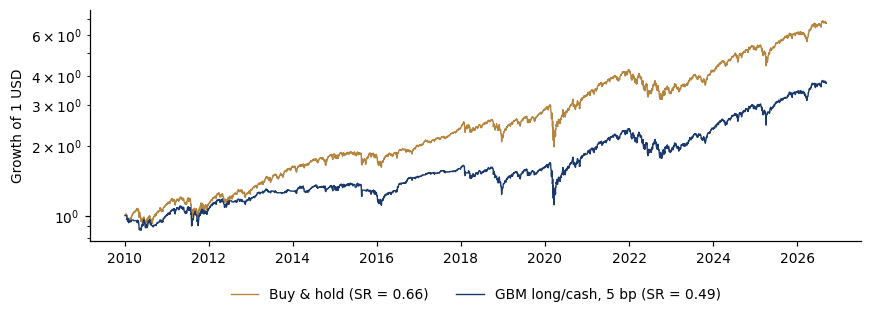

expunere = 79%, tranzacții pe an = 30.4


In [14]:
cost_bp = 5
ret1 = log_spx.diff().shift(-1).reindex(df.index)             # randamentul zilei următoare
signal = pd.Series(np.nan, index=df.index)
for yr in range(2010, df.index[-1].year + 1):
    test = df.index[df.index.year == yr]
    train = df.index[df['t1'] < test[0]]                        # fereastră de antrenare purjată
    m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=150,
                                       min_samples_leaf=100, random_state=SEED)
    m.fit(df.loc[train, FEATS], df.loc[train, 'y'])
    signal.loc[test] = (m.predict_proba(df.loc[test, FEATS])[:, 1] > 0.5).astype(float)
pos_ = signal.dropna()
turnover = pos_.diff().abs().fillna(pos_.iloc[0])
strat = (pos_ * ret1.loc[pos_.index] - turnover * cost_bp / 1e4).dropna()
bh = ret1.loc[strat.index]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(bh.index, np.exp(bh.cumsum()), color=Amber, lw=0.9, label=f'Buy & hold (SR = {sharpe_ratio(bh):.2f})')
ax.plot(strat.index, np.exp(strat.cumsum()), color=MainBlue, lw=0.9,
        label=f'GBM long/cash, {cost_bp} bp (SR = {sharpe_ratio(strat):.2f})')
ax.set_yscale('log'); ax.set_ylabel('Growth of 1 USD'); legend_bottom(ax, ncol=2, y=-0.15)
plt.tight_layout(); plt.show()
print(f'expunere = {pos_.mean():.0%}, tranzacții pe an = {turnover.sum() / (len(pos_) / 252):.1f}')

## 11. Teorema strategiei false

Testăm $N$ strategii independente cu raport Sharpe real **zero**. Rapoartele Sharpe estimate sunt
aproximativ $\mathcal N(0, V[\widehat{SR}])$, iar **maximul** lor așteptat este
(Bailey & López de Prado, 2014)
$$E\big[\max_n \widehat{SR}_n\big] \approx \sqrt{V[\widehat{SR}]}\left((1-\gamma)\,\Phi^{-1}\!\Big(1-\frac1N\Big) + \gamma\,\Phi^{-1}\!\Big(1-\frac{1}{Ne}\Big)\right),$$
unde $\gamma \approx 0.5772$ este constanta Euler–Mascheroni. Cu 5 ani de date zilnice,
$V[\widehat{SR}_{an}] \approx 1/5$, deci testarea a ~100 de strategii produce un Sharpe anualizat peste 1 **doar din noroc**.

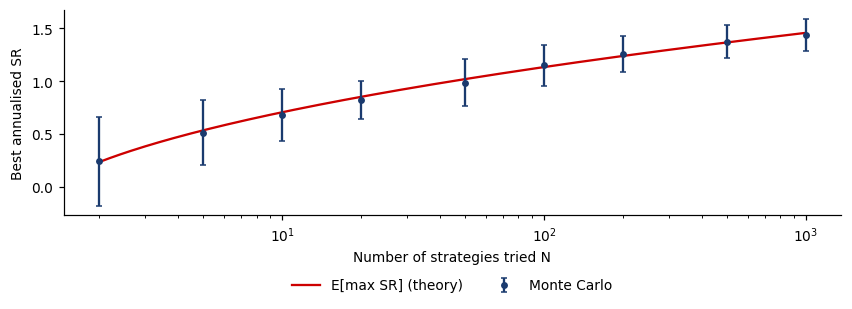

In [15]:
EULER_GAMMA = 0.5772156649015329


def probabilistic_sharpe_ratio(sr, sr_benchmark, T, skew=0.0, kurt=3.0):
    """PSR(SR*) = Phi((SR - SR*) sqrt(T-1) / sqrt(1 - g3 SR + (g4 - 1)/4 SR^2)); SR pe perioadă, kurt = kurtosis brut (distribuția Normală = 3)."""
    denom = np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return stats.norm.cdf((sr - sr_benchmark) * np.sqrt(T - 1) / denom)


def expected_max_sharpe(n_trials, sr_std=1.0):
    """Teorema strategiei false: E[max SR] ~ sqrt(V[SR]) ((1-g) Phi^-1(1-1/N) + g Phi^-1(1-1/(N e)))."""
    n = np.asarray(n_trials, dtype=float)
    return sr_std * ((1 - EULER_GAMMA) * stats.norm.ppf(1 - 1 / n)
                     + EULER_GAMMA * stats.norm.ppf(1 - 1 / (n * np.e)))


def deflated_sharpe_ratio(sr, T, n_trials, sr_std, skew=0.0, kurt=3.0):
    """DSR = PSR(SR_0), SR_0 = E[max SR] sub ipoteza nulă de lipsă a abilității."""
    return probabilistic_sharpe_ratio(sr, expected_max_sharpe(n_trials, sr_std), T, skew, kurt)


rng = np.random.default_rng(SEED)
T = 252 * 5
Ns = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
sim = []
for N in Ns:
    best_sr = []
    for _ in range(100):                                   # 100 de repetiții Monte Carlo
        r_ = rng.normal(0, 0.01, size=(N, T))
        best_sr.append((np.sqrt(252) * r_.mean(1) / r_.std(1, ddof=1)).max())
    sim.append((np.mean(best_sr), np.std(best_sr)))
sim = np.array(sim)
grid = np.logspace(np.log10(2), 3, 200)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(grid, expected_max_sharpe(grid, sr_std=np.sqrt(252 / T)), color=IDAred, label='E[max SR] (theory)')
ax.errorbar(Ns, sim[:, 0], yerr=sim[:, 1], fmt='o', ms=3.5, color=MainBlue, capsize=2, label='Monte Carlo')
ax.set_xscale('log'); ax.set_xlabel('Number of strategies tried N'); ax.set_ylabel('Best annualised SR')
legend_bottom(ax, ncol=2); plt.tight_layout(); plt.show()

## 12. Probabilistic și Deflated Sharpe Ratio

**Probabilistic Sharpe Ratio** dă probabilitatea ca SR real să depășească un reper $SR^*$, corectând pentru
lungimea eșantionului $T$, asimetrie $\hat\gamma_3$ și kurtosis $\hat\gamma_4$ (SR pe perioadă):
$$\mathrm{PSR}(SR^*) = \Phi\!\left(\frac{(\widehat{SR}-SR^*)\sqrt{T-1}}{\sqrt{1-\hat\gamma_3\widehat{SR}+\frac{\hat\gamma_4-1}{4}\widehat{SR}^2}}\right).$$
**Deflated Sharpe Ratio** fixează reperul la maximul așteptat sub ipoteza nulă,
$\mathrm{DSR} = \mathrm{PSR}\big(E[\max \widehat{SR}_n]\big)$, penalizând astfel numărul de încercări $N$.
O regulă uzuală: acceptăm o strategie doar dacă DSR > 0,95.

SR anualizat = 0.49, skew = -0.65, kurtosis = 20.8, T = 4198
PSR(0) = 0.976
N =   2: DSR = 0.928
N =   5: DSR = 0.788
N =  20: DSR = 0.540
N = 100: DSR = 0.301


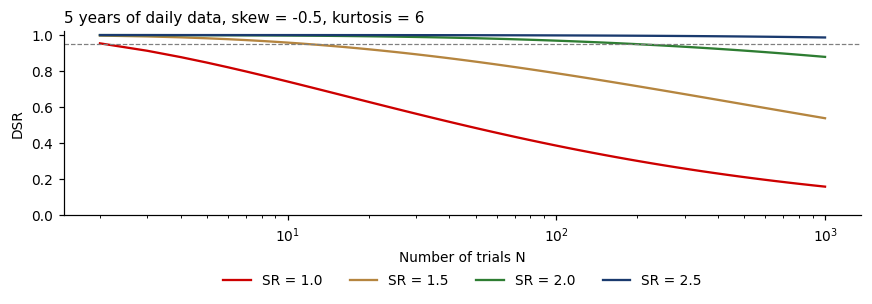

In [16]:
# aplicăm pe strategia walk-forward din Secțiunea 10
T_s = len(strat)
sr_d = strat.mean() / strat.std()                                  # SR zilnic (pe perioadă)
sk, ku = stats.skew(strat), stats.kurtosis(strat, fisher=False)
print(f'SR anualizat = {sr_d * np.sqrt(252):.2f}, skew = {sk:.2f}, kurtosis = {ku:.1f}, T = {T_s}')
print(f'PSR(0) = {probabilistic_sharpe_ratio(sr_d, 0, T_s, sk, ku):.3f}')
for N in [2, 5, 20, 100]:
    print(f'N = {N:>3}: DSR = {deflated_sharpe_ratio(sr_d, T_s, N, np.sqrt(1 / T_s), sk, ku):.3f}')

T = 252 * 5
Ngrid = np.unique(np.logspace(np.log10(2), 3, 60).astype(int))
fig, ax = plt.subplots(figsize=(8, 3))
for sr_ann, c in zip([1.0, 1.5, 2.0, 2.5], [IDAred, Amber, Forest, MainBlue]):
    ax.plot(Ngrid, deflated_sharpe_ratio(sr_ann / np.sqrt(252), T, Ngrid, np.sqrt(1 / T), -0.5, 6.0),
            color=c, label=f'SR = {sr_ann}')
ax.axhline(0.95, color=Gray, ls='--', lw=0.8); ax.set_xscale('log'); ax.set_ylim(0, 1.02)
ax.set_xlabel('Number of trials N'); ax.set_ylabel('DSR'); legend_bottom(ax, ncol=4)
ax.set_title('5 years of daily data, skew = -0.5, kurtosis = 6', loc='left')
plt.tight_layout(); plt.show()

## Concluzii

1. În finanțe, raportul semnal/zgomot este foarte mic: **validarea** modelului contează mai mult decât **alegerea** lui.
2. Facem datele staționare fără a le distruge memoria (FFD) și etichetăm rezultatele așa cum ar face-o un trader (trei bariere).
3. Etichetele suprapuse cer validare încrucișată **purjată**, cu embargo; K-Fold cu amestecare poate „fabrica" semnal din zgomot.
4. Comparăm cu reperul corect („mereu în sus", buy-and-hold) și includem costurile de tranzacționare.
5. Înregistrăm **toate** încercările: cel mai bun backtest din $N$ trebuie „deflatat" (DSR) înainte de a-l crede.

**Aprofundare (Quantinar):** [Random Forests](https://quantinar.com/course/68/RF) ·
[Shapley Values](https://quantinar.com/course/48/shapley) ·
[Machine learning in Financial Risk](https://quantinar.com/course/934/machine-learning-in-financial-risk) ·
[Introduction to Reinforcement Learning](https://quantinar.com/course/36/ReinforcementLearning)